# **🌧️ Australia Rain Prediction Model**

The Rain in Australia Dataset contains about 10 years of daily weather observations sourced from numerous weather stations across the country. It is designed to assist in building predictive models that can determine weather patterns and target meteorological forecasts.

The dataset contains structured information about various daily climate metrics, including temperature ranges, rainfall amounts, wind speeds, humidity, atmospheric pressure, and cloud cover. It reflects historical weather data across multiple geographical locations in Australia. This dataset is designed to support exploratory data analysis, data visualization, and machine learning model development for binary classification tasks.

### **Dataset Overview**
This dataset contains about 10 years of daily weather observations from numerous Australian weather stations.

RainTomorrow is the target variable to predict. It means — did it rain the next day, Yes or No?
This column is Yes if the rain for that day was 1mm or more.

<div style="display: flex; gap: 20px;">
  <div style="flex: 1;">

| Feature | Description |
| :--- | :--- |
| **Date** | The date of observation |
| **Location** | The common name of the location |
| **MinTemp** | Minimum temperature (°C) |
| **MaxTemp** | Maximum temperature (°C) |
| **Rainfall** | Rainfall recorded for the day (mm) |
| **Evaporation** | Class A pan evaporation (mm) |
| **Sunshine** | Hours of bright sunshine |
| **WindGustDir** | Direction of strongest wind gust |
| **WindGustSpeed** | Speed of strongest wind gust (km/h) |
| **WindDir9am** | Direction of the wind at 9am |
| **WindDir3pm** | Direction of the wind at 3pm |
| **WindSpeed9am** | Wind speed prior to 9am (km/h) |

  </div>
  <div style="flex: 1;">

| Feature | Description |
| :--- | :--- |
| **WindSpeed3pm** | Wind speed prior to 3pm (km/h) |
| **Humidity9am** | Humidity percent at 9am |
| **Humidity3pm** | Humidity percent at 3pm |
| **Pressure9am** | Atmospheric pressure at 9am (hpa) |
| **Pressure3pm** | Atmospheric pressure at 3pm (hpa) |
| **Cloud9am** | Cloud fraction at 9am (oktas) |
| **Cloud3pm** | Cloud fraction at 3pm (oktas) |
| **Temp9am** | Temperature at 9am (°C) |
| **Temp3pm** | Temperature at 3pm (°C) |
| **RainToday** | 1 if rainfall > 1mm today, else 0 |
| **RainTomorrow** | **Target:** Rain tomorrow? (Yes/No) |
| | |

  </div>
</div>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
from matplotlib import pyplot as plt

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/jsphyg/weather-dataset-rattle-package/weatherAUS.csv


In [2]:
data = pd.read_csv('/kaggle/input/datasets/jsphyg/weather-dataset-rattle-package/weatherAUS.csv')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null

In [3]:
# 1. Start fresh by dropping rows where target labels are missing
data = data.dropna(subset=['RainToday', 'RainTomorrow'])

# 2. Extract Month for seasonal grouping
data['Date'] = pd.to_datetime(data['Date'])
data['Month'] = data['Date'].dt.month

# 3. Step 1 Imputation: Fill missing values by specific Location & Month mean
num_cols = data.select_dtypes(include=['float64']).columns
for col in num_cols:
    data[col] = data.groupby(['Location', 'Month'])[col].transform(lambda x: x.fillna(x.mean()))

# 4. Step 2 Imputation: For stations completely lacking Evaporation/Sunshine data for a whole month,
# fill remaining NaNs with the national mean for that specific month.
for col in num_cols:
    if data[col].isnull().sum() > 0:
        data[col] = data.groupby(['Month'])[col].transform(lambda x: x.fillna(x.mean()))

# 5. Impute Categorical Columns (using mode of specific Location)
cat_cols = ['WindGustDir', 'WindDir9am', 'WindDir3pm']
for col in cat_cols:
    data[col] = data.groupby('Location')[col].transform(
        lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 'Unknown')
    )

# 6. Clean up temporary column
data = data.drop(columns=['Month'])

print("Remaining null values:")
print(data.isnull().sum())

Remaining null values:
Date             0
Location         0
MinTemp          0
MaxTemp          0
Rainfall         0
Evaporation      0
Sunshine         0
WindGustDir      0
WindGustSpeed    0
WindDir9am       0
WindDir3pm       0
WindSpeed9am     0
WindSpeed3pm     0
Humidity9am      0
Humidity3pm      0
Pressure9am      0
Pressure3pm      0
Cloud9am         0
Cloud3pm         0
Temp9am          0
Temp3pm          0
RainToday        0
RainTomorrow     0
dtype: int64


In [4]:
data.shape

(140787, 23)

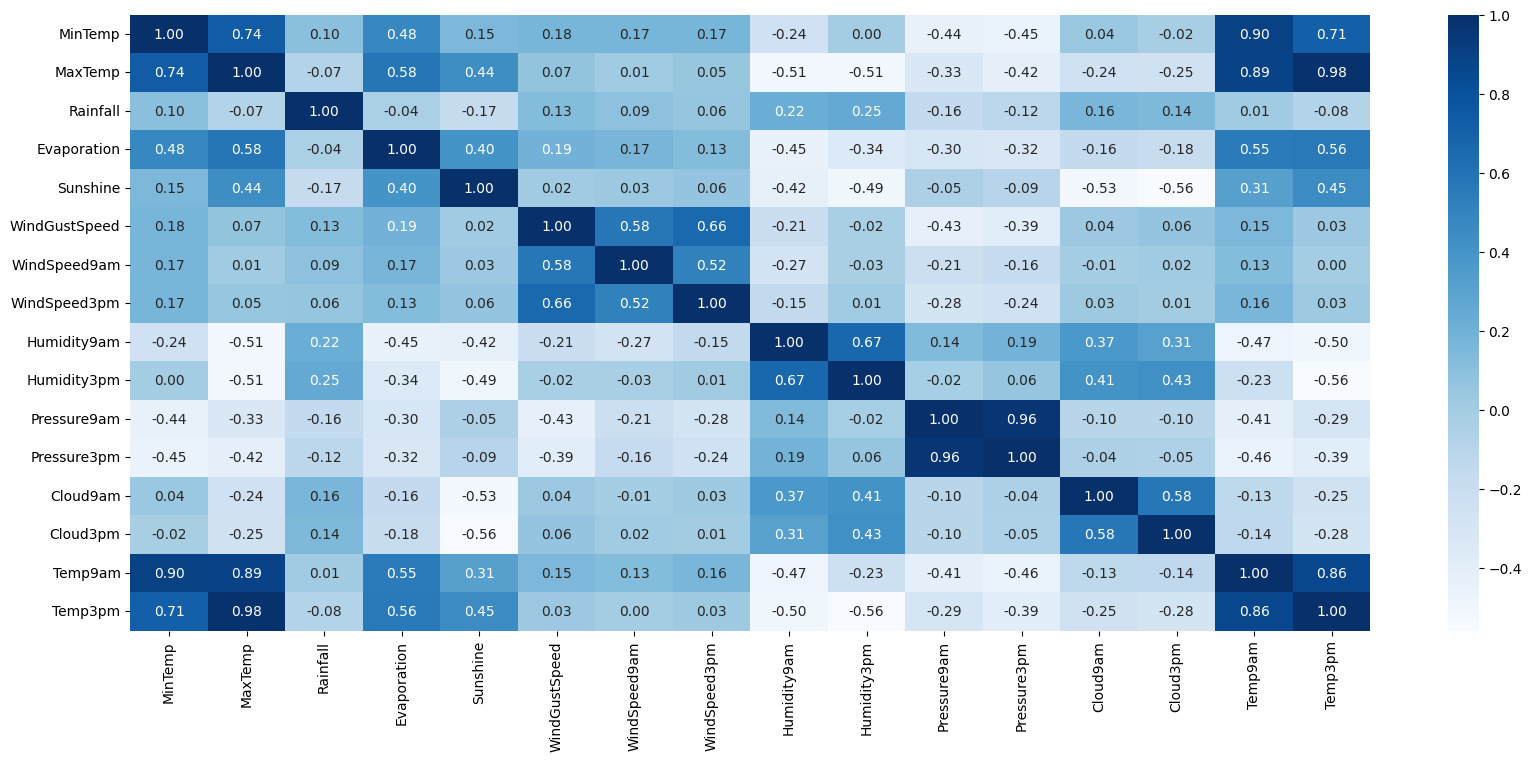

In [5]:
corr_data = data.corr(numeric_only=True)
plt.figure(figsize=(20, 8))
sns.heatmap(corr_data, annot=True, fmt='.2f', cmap="Blues")
plt.show()

* **`MaxTemp` & `Temp3pm` ($0.98$):** Afternoon temperatures almost perfectly dictate the day's maximum temperature.
* **`Pressure9am` & `Pressure3pm` ($0.96$):** Barometric pressure remains incredibly stable between morning and afternoon.
* **`MinTemp` & `Temp9am` ($0.90$):** Morning temperature is heavily driven by overnight lows.
* **Clouds vs. Sunshine ($-0.53$ to $-0.56$):** Strong negative correlation—more cloud cover directly cuts down sunshine hours.
* **Temperature vs. Humidity ($-0.42$ to $-0.56$):** As afternoon temperatures rise, relative humidity drops significantly.
* **Temperature vs. Evaporation ($0.48$ to $0.58$):** Warmer days directly accelerate water evaporation.
* **`WindGustSpeed` & `WindSpeed3pm` ($0.66$):** The peak wind gust of the day is much more closely tied to afternoon wind speeds than morning wind speeds ($0.58$).

* **`Rainfall` has very low linear correlation** with all other features (maxing out around $0.25$ with humidity). Because rainfall behaves non-linearly, **tree-based models** (like Random Forest, LightGBM, or XGBoost) will likely perform much better on this dataset than linear models like Logistic Regression.

In [6]:
data['Location'].value_counts()

Location
Canberra            3402
Sydney              3331
Perth               3193
Darwin              3192
Hobart              3183
Brisbane            3132
Bendigo             3030
Townsville          3027
AliceSprings        3025
MountGambier        3022
Launceston          3020
Adelaide            3020
Ballarat            3017
PerthAirport        3009
MelbourneAirport    3009
Mildura             3005
SydneyAirport       3001
Nuriootpa           2996
Albany              2996
Sale                2992
Albury              2991
Watsonia            2990
Portland            2984
Woomera             2984
Cobar               2980
Cairns              2964
Tuggeranong         2959
WaggaWagga          2958
NorfolkIsland       2944
Wollongong          2943
SalmonGums          2941
CoffsHarbour        2940
Dartmoor            2939
Newcastle           2929
GoldCoast           2924
Witchcliffe         2924
Penrith             2911
Richmond            2906
NorahHead           2888
BadgerysCreek   

/tmp/ipykernel_16/3177326513.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_data = city_data.set_index('Date').resample('M').mean(numeric_only=True).reset_index()


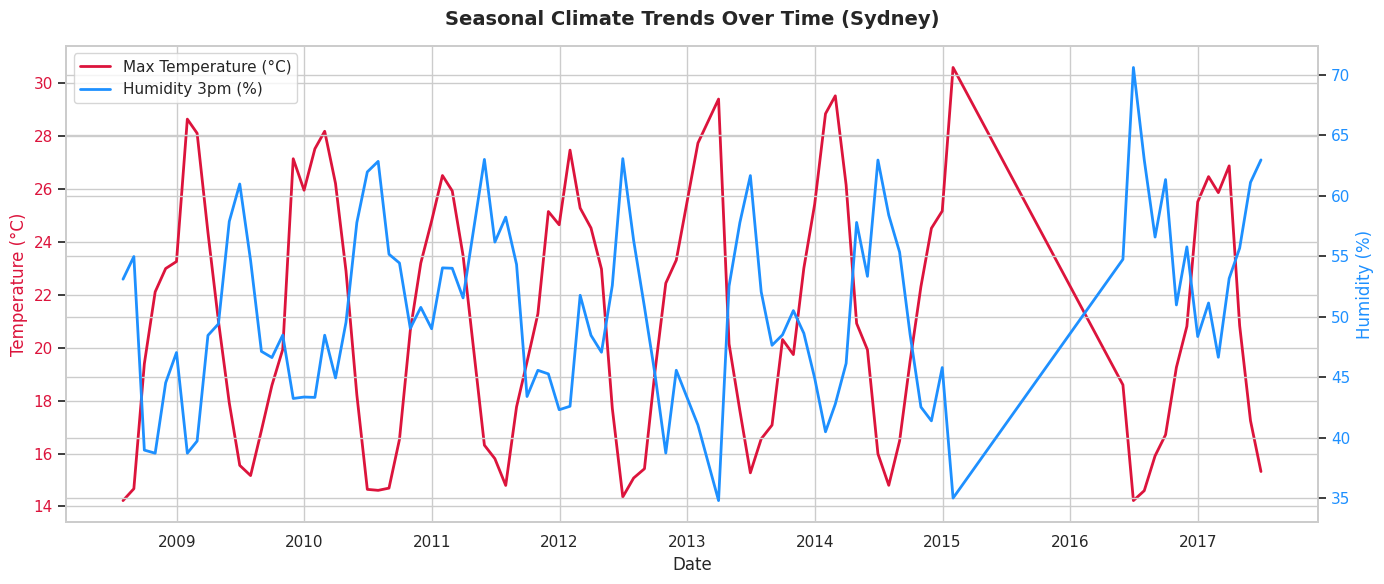

In [7]:
# Filter for a specific location to see a clear local timeline
# (Plotting all locations at once creates overlapping timeline noise)
city_data = data[data['Location'] == 'Melbourne'].sort_values('Date')

# Resample by month to smooth out daily noise and see clear seasonal cycles
monthly_data = city_data.set_index('Date').resample('M').mean(numeric_only=True).reset_index()

plt.figure(figsize=(14, 6))
sns.set_theme(style="whitegrid")

# Axis 1: Temperature (Left Side)
ax1 = sns.lineplot(data=monthly_data, x='Date', y='MaxTemp', color='crimson', label='Max Temperature (°C)', linewidth=2)
ax1.set_ylabel('Temperature (°C)', color='crimson', fontsize=12)
ax1.tick_params(axis='y', labelcolor='crimson')
ax1.set_title('Seasonal Climate Trends Over Time (Sydney)', fontsize=14, fontweight='bold', pad=15)

# Axis 2: Humidity (Right Side - Twin Axis)
ax2 = ax1.twinx()
sns.lineplot(data=monthly_data, x='Date', y='Humidity3pm', color='dodgerblue', ax=ax2, label='Humidity 3pm (%)', linewidth=2)
ax2.set_ylabel('Humidity (%)', color='dodgerblue', fontsize=12)
ax2.tick_params(axis='y', labelcolor='dodgerblue')

# 4. Handle legends from both axes gracefully
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.get_legend().remove() # Remove original to avoid duplicates
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left', frameon=True)

plt.tight_layout()
plt.show()

In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier # or from xgboost import XGBClassifier
import xgboost as xgb

# 1. Encode Target and Categorical variables
le = LabelEncoder()
df_model = data.copy()

# Map Target to 0 and 1
df_model['RainTomorrow'] = le.fit_transform(df_model['RainTomorrow'])
df_model['RainToday'] = le.fit_transform(df_model['RainToday'])

# Convert remaining object columns (like Location, Wind Directions) to category codes
for col in df_model.select_dtypes(include=['object']).columns:
    df_model[col] = df_model[col].astype('category').cat.codes

# 2. Define Features (X) and Target (y)
# Dropping Date as it's a datetime object, and highly collinear features found in EDA
X = df_model.drop(columns=['RainTomorrow', 'Date', 'Temp3pm', 'Temp9am', 'Pressure9am'])
y = df_model['RainTomorrow']

# 3. Split into Train (80%) and Test (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Initialize Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1),
    "XGBoost": xgb.XGBClassifier(n_estimators=100, max_depth=6, random_state=42, eval_metric='logloss')
}

# 5. Train and Evaluate
results = {}
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    accuracy = model.score(X_test, y_test)
    results[name] = f"{accuracy:.2%}"

# 6. Display Performance
print("\n=== Model Accuracy Comparison ===")
for model_name, score in results.items():
    print(f"{model_name}: {score}")

Training Logistic Regression...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Training Random Forest...
Training XGBoost...

=== Model Accuracy Comparison ===
Logistic Regression: 84.49%
Random Forest: 85.62%
XGBoost: 86.34%
